In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import tensorflow as tf

from sklearn.model_selection import train_test_split # 데이터셋 분리
from sklearn.model_selection import cross_val_score #교차검증
from sklearn.model_selection import KFold 

from sklearn.neighbors import KNeighborsClassifier     #KNN
from sklearn.neighbors import NearestCentroid          #NCN
from sklearn.svm import SVC                            #SVM
from sklearn.naive_bayes import GaussianNB             #NB
from sklearn.tree import DecisionTreeClassifier        #DT
from sklearn.ensemble import RandomForestClassifier    #RF
from sklearn.ensemble import GradientBoostingClassifier#GB
from sklearn.ensemble import AdaBoostClassifier        #AB

from sklearn.ensemble import VotingClassifier

import warnings
warnings.filterwarnings(action='ignore')
#라이브러리

# import dataset

In [2]:
train=pd.read_csv('C:/Users/Lee/Desktop/공부/2021-1학기/머신러닝-빅데이터/train.csv ')

In [3]:
test=pd.read_csv('C:/Users/Lee/Desktop/공부/2021-1학기/머신러닝-빅데이터/test.csv ')
pi=test.PassengerId

In [4]:
titanic=pd.concat([train,test],ignore_index=True)
#ignore_index=True 는 두 데이터 프레임 합칠때 인덱스를 통일한다.

In [5]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
print(train.shape)
print(train.info())

print('-'*50)
print(test.shape)
print(test.info())

print('-'*50)
print(titanic.shape)
print(titanic.info())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
--------------------------------------------------
(418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       ---

#### 수치형 특성 7, 객체타입 특성 5
####  age,cabic,emvarked 결측치 존재

In [7]:
print(train.isnull().sum())
test.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

특성	|설명 |	Type
:-------:|:------:|:-----:
PassengerId	|승객 번호|	연속형
Survived|	생존여부(1: 생존, 0 : 사망)|	범주형(이진)
Pclass|	승선권 클래스(1 : 1st, 2 : 2nd ,3 : 3rd)|	범주형
Name|	승객 이름|	문자형
Sex	|승객 성별	|범주형(이진, 남자 or 여자)
Age	|승객 나이	|연속형
SibSp|	동반한 형제자매, 배우자 수|	연속형
Parch|	동반한 부모, 자식 수	|연속형
Ticket|	티켓의 고유 넘버	|문자형
Fare	|티켓의 요금	|연속형
Cabin	|객실 번호	|문자형
Embarked|	승선한 항구명(C : Cherbourg, Q : Queenstown, S : Southampton)|	범주형

In [8]:
train.describe(include='all')
#describe 메소드의 defulte값은 수치형 자료만 요약한다. 따라서 include='all' 을 주어 모든 변수에 대한 요약값 리턴

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


#### 생존확률 약38%
#### 남성이 577명으로 여성보다 많다
#### fare  max값이 mean값과 10배 이상 차이나는 이상치 존재
#### embarked S가 644개로 대다수를 차지한다.  

In [9]:
train.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### 시각화를 통한 특성 탐색

In [10]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## 1.PassengerId

In [11]:
train.PassengerId

0        1
1        2
2        3
3        4
4        5
      ... 
886    887
887    888
888    889
889    890
890    891
Name: PassengerId, Length: 891, dtype: int64

#### PassengerId 특성은 데이터 값이 인덱스 값과 같기에 survived 분류에서 제외한다.

In [12]:
test=test.drop('PassengerId',axis=1)
train=train.drop('PassengerId',axis=1)
train

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 2.Pclass

In [13]:
train[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean()

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


<AxesSubplot:xlabel='Pclass', ylabel='count'>

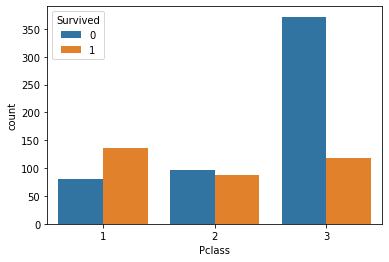

In [14]:
sns.countplot("Pclass",hue='Survived',data=train)

#### Pclass 등급에 따라 생존에 유의미한 차이를 보인다.

## 3.Name

In [15]:
train.Name.head(15)

0                               Braund, Mr. Owen Harris
1     Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                Heikkinen, Miss. Laina
3          Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                              Allen, Mr. William Henry
5                                      Moran, Mr. James
6                               McCarthy, Mr. Timothy J
7                        Palsson, Master. Gosta Leonard
8     Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                   Nasser, Mrs. Nicholas (Adele Achem)
10                      Sandstrom, Miss. Marguerite Rut
11                             Bonnell, Miss. Elizabeth
12                       Saundercock, Mr. William Henry
13                          Andersson, Mr. Anders Johan
14                 Vestrom, Miss. Hulda Amanda Adolfina
Name: Name, dtype: object

#### 이름에서 호칭과. 이 나온다 따라서 Name특성에서 호칭을 뽑는다

In [16]:
test['Name']=test.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
train['Name']=train.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

In [17]:
train.Name.value_counts()

Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: Name, dtype: int64

#### Name의 종류를 5가지로 축약시킨다

In [18]:
train['Name'] = np.where(train['Name'].isin(['Mr','Miss','Mrs','Master']), train['Name'], 'Others')
test['Name'] = np.where(test['Name'].isin(['Mr','Miss','Mrs','Master']), test['Name'], 'Others')
print(train['Name'].value_counts())    
test['Name'].value_counts()

Mr        517
Miss      182
Mrs       125
Master     40
Others     27
Name: Name, dtype: int64


Mr        240
Miss       78
Mrs        72
Master     21
Others      7
Name: Name, dtype: int64

In [19]:
name_f={"Mr":1,"Miss":2,"Mrs":3,"Master":4,"Others":5}
train.Name=train.Name.map(name_f)
test.Name=test.Name.map(name_f)

,Name,Survived
2,3,0.792000
1,2,0.697802
3,4,0.575000
4,5,0.444444
0,1,0.156673


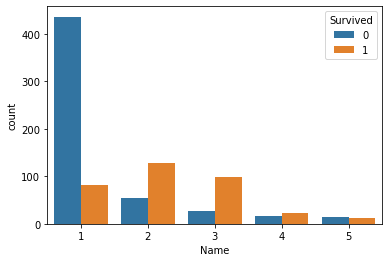

In [20]:
sns.countplot("Name",hue='Survived',data=train)
train[['Name', 'Survived']].groupby(['Name'], as_index=False).mean().sort_values(by='Survived', ascending=False)

In [21]:
train[['Name','Age']].groupby(['Name'], as_index=False).mean()

,Name,Age
0,1,32.368090
1,2,21.773973
2,3,35.898148
3,4,4.574167
4,5,42.384615


#### 위의 자료를 통해 Miss호칭인 성인 남성이 가장 높은 사망율을 보였고
#### Mrs ,Miss 같이 여성들은 높은 생존율을 보인다

## 4.Sex

In [22]:
train.Sex.value_counts()

male      577
female    314
Name: Sex, dtype: int64

In [23]:
train[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [24]:
test.Sex=train.Sex.map({'female':1,'male':0}).astype(int)
train.Sex=train.Sex.map({'female':1,'male':0}).astype(int)


<AxesSubplot:xlabel='Sex', ylabel='count'>

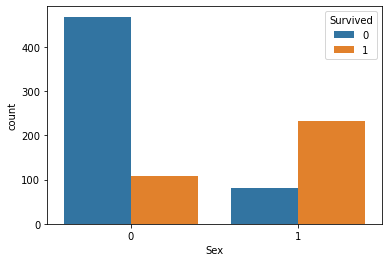

In [25]:
sns.countplot("Sex",hue='Survived',data=train)

## 5.Age

In [26]:
print(train.Age.isnull().sum())
train.Age.isnull().sum()

177


177

In [27]:
a=[train[['Name','Age']].groupby(['Name'], as_index=False).median()]
a

[   Name   Age
 0     1  30.0
 1     2  21.0
 2     3  35.0
 3     4   3.5
 4     5  44.5]

In [28]:
li=[train,test]
for i in li:
    i.loc[(i.Age.isnull()) & (i.Name== 1),'Age']=30
    i.loc[(i.Age.isnull()) & (i.Name== 2),'Age']=21
    i.loc[(i.Age.isnull()) & (i.Name== 3),'Age']=35
    i.loc[(i.Age.isnull()) & (i.Name== 4),'Age']=4
    i.loc[(i.Age.isnull()) & (i.Name== 5),'Age']=45

(array([ 58.,  46., 213., 288., 135.,  71.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

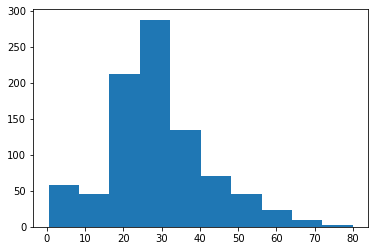

In [29]:
plt.hist("Age",data=train)

In [30]:
 q20, q40, q60 ,q80 = np.percentile(train.Age, [20, 40,60,80])


In [31]:
print(q20,q40, q60, q80)

20.0 26.0 30.0 38.0


In [32]:
for i in li:
    i.loc[i.Age<=q20,'Age']=1
    i.loc[(i.Age>q20) & (i.Age<=q40),'Age']=2
    i.loc[(i.Age>q40) & (i.Age<=q60),'Age']=3
    i.loc[(i.Age>q60) & (i.Age<=q80),'Age']=4
    i.loc[i.Age>q80,'Age']=5

<AxesSubplot:xlabel='Age', ylabel='count'>

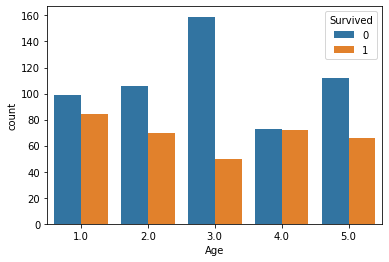

In [33]:
sns.countplot("Age",hue='Survived',data=train)

#### Age30~38세의 생존율이 낮다.

## 6. SibSp Parch

#### 두 변수는 가족의 수이므로 조건을 동일하게 설정한다.

In [34]:
train.SibSp.value_counts()

0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64

In [35]:
test.loc[test.SibSp>=3,'SibSp']=3
train.loc[train.SibSp>=3,'SibSp']=3

,SibSp,Survived
0,0,0.345395
1,1,0.535885
2,2,0.464286
3,3,0.152174


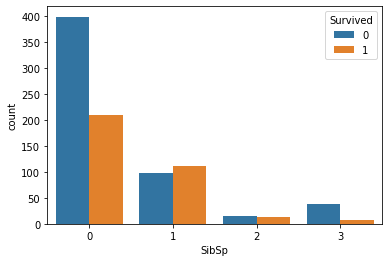

In [36]:
sns.countplot("SibSp",hue='Survived',data=train)
train[['SibSp','Survived']].groupby(['SibSp'], as_index=False).mean()

In [37]:
train.Parch.value_counts()

0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64

In [38]:
test.loc[train.Parch>=3,'Parch']=3
train.loc[train.Parch>=3,'Parch']=3

,Parch,Survived
0,0,0.343658
1,1,0.550847
2,2,0.500000
3,3,0.266667


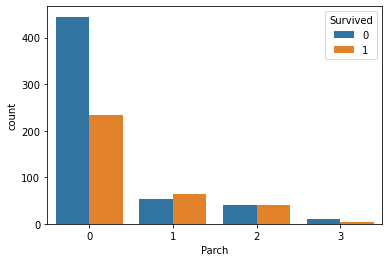

In [39]:
sns.countplot("Parch",hue='Survived',data=train)
train[['Parch','Survived']].groupby(['Parch'], as_index=False).mean()

In [40]:
test['family']=test.Parch+test.SibSp
train['family']=train.Parch+train.SibSp

In [41]:
test.loc[test.family>=5,'family']=5

,family,Survived
0,0,0.303538
1,1,0.552795
2,2,0.578431
3,3,0.656250
4,4,0.133333
5,5,0.206897


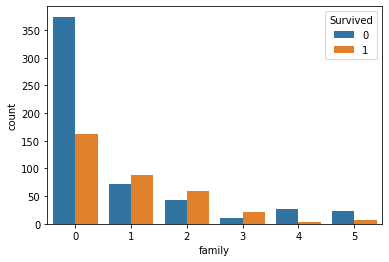

In [42]:
sns.countplot("family",hue='Survived',data=train)
train[['family','Survived']].groupby(['family'], as_index=False).mean()

####  가족이 없을 때 보다 가족의 수가 1명~3명일때 생존확률이 오름을 알수있다.

In [43]:
train=train.drop('Parch',axis=1)
train=train.drop('SibSp',axis=1)
test=test.drop('Parch',axis=1)
test=test.drop('SibSp',axis=1)

In [44]:
test

,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,family
0,3,1,0,4.0,330911,7.8292,NaN,Q,0
1,3,3,1,5.0,363272,7.0000,NaN,S,1
2,2,1,1,5.0,240276,9.6875,NaN,Q,0
3,3,1,1,3.0,315154,8.6625,NaN,S,0
4,3,3,0,2.0,3101298,12.2875,NaN,S,2
...,...,...,...,...,...,...,...,...,...
413,3,1,0,3.0,A.5. 3236,8.0500,NaN,S,0
414,1,5,0,5.0,PC 17758,108.9000,C105,C,0
415,3,1,1,5.0,SOTON/O.Q. 3101262,7.2500,NaN,S,0
416,3,1,1,3.0,359309,8.0500,NaN,S,0


In [45]:
train

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,family
0,0,3,1,0,2.0,A/5 21171,7.2500,NaN,S,1
1,1,1,3,1,4.0,PC 17599,71.2833,C85,C,1
2,1,3,2,1,2.0,STON/O2. 3101282,7.9250,NaN,S,0
3,1,1,3,1,4.0,113803,53.1000,C123,S,1
4,0,3,1,0,4.0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,5,0,3.0,211536,13.0000,NaN,S,0
887,1,1,2,1,1.0,112053,30.0000,B42,S,0
888,0,3,2,1,2.0,W./C. 6607,23.4500,NaN,S,3
889,1,1,1,0,2.0,111369,30.0000,C148,C,0


## 7.Ticket

In [46]:
train.Ticket.describe()

count        891
unique       681
top       347082
freq           7
Name: Ticket, dtype: object

####  unique 값이 681개이며 티켓의 고유 숫자이기에  드랍한다 

In [47]:
test=test.drop('Ticket',axis=1)
train=train.drop('Ticket',axis=1)

## 8.Fare

In [48]:
print(test.Fare.isnull().sum())
train.Fare.isnull().sum()

1


0

In [49]:
train.Fare.describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

(array([732., 106.,  31.,   2.,  11.,   6.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  51.23292, 102.46584, 153.69876, 204.93168, 256.1646 ,
        307.39752, 358.63044, 409.86336, 461.09628, 512.3292 ]),
 <BarContainer object of 10 artists>)

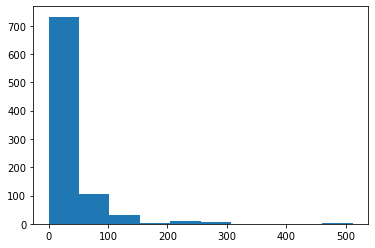

In [50]:
plt.hist(train.Fare)

{'whiskers': [<matplotlib.lines.Line2D at 0x14fe4cf3b50>,
 'caps': [<matplotlib.lines.Line2D at 0x14fe4cff250>,
 'boxes': [<matplotlib.lines.Line2D at 0x14fe4cf37f0>],
 'medians': [<matplotlib.lines.Line2D at 0x14fe4cff910>],
 'fliers': [<matplotlib.lines.Line2D at 0x14fe4cffc70>],
 'means': []}

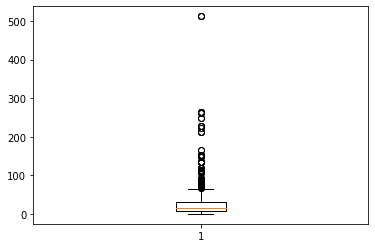

In [51]:
plt.boxplot(train.Fare)

In [52]:
train[train.Fare>300]

,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,family
258,1,1,2,1,4.0,512.3292,NaN,C,0
679,1,1,1,0,4.0,512.3292,B51 B53 B55,C,1
737,1,1,1,0,4.0,512.3292,B101,C,0


#### Fare의 값이 300이상인 경우 Pclass는 1등석 이므로 삭제하지 않는다

In [53]:
train[['Pclass','Fare']].groupby(['Pclass'], as_index=False).mean()

,Pclass,Fare
0,1,84.154687
1,2,20.662183
2,3,13.675550


In [54]:
train[train.Fare==0]

,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,family
179,0,3,1,0,4.0,0.0,NaN,S,0
263,0,1,1,0,5.0,0.0,B94,S,0
271,1,3,1,0,2.0,0.0,NaN,S,0
277,0,2,1,0,3.0,0.0,NaN,S,0
302,0,3,1,0,1.0,0.0,NaN,S,0
413,0,2,1,0,3.0,0.0,NaN,S,0
466,0,2,1,0,3.0,0.0,NaN,S,0
481,0,2,1,0,3.0,0.0,NaN,S,0
597,0,3,1,0,5.0,0.0,NaN,S,0
633,0,1,1,0,3.0,0.0,NaN,S,0


In [55]:
test.describe()

,Pclass,Name,Sex,Age,Fare,family
count,418.000000,418.000000,418.000000,418.000000,417.000000,418.000000
mean,2.265550,1.748804,0.382775,2.971292,35.627188,0.794258
std,0.841838,1.018562,0.486647,1.388248,55.907576,1.239156
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,2.000000,7.895800,0.000000
50%,3.000000,1.000000,0.000000,3.000000,14.454200,0.000000
75%,3.000000,2.000000,1.000000,4.000000,31.500000,1.000000
max,3.000000,5.000000,1.000000,5.000000,512.329200,5.000000


In [56]:
test[test.Fare.isnull()]

,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,family
152,3,1,0,5.0,NaN,NaN,S,0


In [57]:
test[test.Pclass==3].Fare.mean()

12.459677880184334

In [58]:
test['Fare']=test.Fare.fillna(12.45)

In [59]:
test.isnull().sum()

Pclass        0
Name          0
Sex           0
Age           0
Fare          0
Cabin       327
Embarked      0
family        0
dtype: int64

## 9.Cabin

In [60]:
print(train.Cabin.isnull().sum())

687


In [61]:
test=test.drop("Cabin",axis=1)
train=train.drop("Cabin",axis=1)

#### Cabin의 경우 결측치의 값이 687개로  Cabin특성은 삭제한다.


## 10. Embarked

In [62]:
print(test.Embarked.isnull().sum())
print(train.Embarked.isnull().sum())

0
2


In [63]:
train.Embarked.describe()

count     889
unique      3
top         S
freq      644
Name: Embarked, dtype: object

In [64]:
train.Embarked.value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [65]:
train.Embarked = train.Embarked.fillna('S')

In [66]:
test.Embarked.value_counts()

S    270
C    102
Q     46
Name: Embarked, dtype: int64

In [67]:
test[test.Embarked ==5]

,Pclass,Name,Sex,Age,Fare,Embarked,family


In [68]:
train['Embarked'] = train['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int) 

In [69]:
test['Embarked'] = test['Embarked'].map( {'S': 0, 'C': 1, 'Q': 2} ).astype(int) 

####  Embarked특성의 경우 결측치 2개의 값을 빈도수가 가장높은 S항구로 대체한다.

원핫인코딩 그리드 서치

In [70]:
train

,Survived,Pclass,Name,Sex,Age,Fare,Embarked,family
0,0,3,1,0,2.0,7.2500,0,1
1,1,1,3,1,4.0,71.2833,1,1
2,1,3,2,1,2.0,7.9250,0,0
3,1,1,3,1,4.0,53.1000,0,1
4,0,3,1,0,4.0,8.0500,0,0
...,...,...,...,...,...,...,...,...
886,0,2,5,0,3.0,13.0000,0,0
887,1,1,2,1,1.0,30.0000,0,0
888,0,3,2,1,2.0,23.4500,0,3
889,1,1,1,0,2.0,30.0000,1,0


In [71]:
test

,Pclass,Name,Sex,Age,Fare,Embarked,family
0,3,1,0,4.0,7.8292,2,0
1,3,3,1,5.0,7.0000,0,1
2,2,1,1,5.0,9.6875,2,0
3,3,1,1,3.0,8.6625,0,0
4,3,3,0,2.0,12.2875,0,2
...,...,...,...,...,...,...,...
413,3,1,0,3.0,8.0500,0,0
414,1,5,0,5.0,108.9000,1,0
415,3,1,1,5.0,7.2500,0,0
416,3,1,1,3.0,8.0500,0,0


## 분석

In [72]:
from sklearn.model_selection import train_test_split,GridSearchCV # 데이터셋 분리
from sklearn.model_selection import cross_val_score,StratifiedKFold #교차검증
from sklearn.model_selection import KFold 

from sklearn.neighbors import KNeighborsClassifier     #KNN
from sklearn.neighbors import NearestCentroid          #NCN
from sklearn.svm import SVC                            #SVM
from sklearn.naive_bayes import GaussianNB             #NB
from sklearn.tree import DecisionTreeClassifier        #DT
from sklearn.ensemble import RandomForestClassifier    #RF
from sklearn.ensemble import GradientBoostingClassifier#GB
from sklearn.ensemble import AdaBoostClassifier        #AB

from sklearn.linear_model import LogisticRegression  #LR

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier


knn=KNeighborsClassifier()                 #knn
ncn = NearestCentroid()                    #NCN
svc=SVC()                                  #SVM
nb=GaussianNB()                            #SVM
dtree=DecisionTreeClassifier()             #DT
rf=RandomForestClassifier()                #RF
gb=GradientBoostingClassifier()            #GB
ab=AdaBoostClassifier()                    #ab
LR= LogisticRegression()
kfold=KFold(shuffle=True,random_state=0)

X=train.iloc[:,1:10]
Y=train.iloc[:,0]

x_train, x_test, y_train, y_test = train_test_split(
     X,Y, random_state=0)


In [73]:
classfier=[knn,ncn,svc,nb,dtree,rf,gb,ab]
name=['knn','ncn','svc','nb','dtree','rf','gb','ab']
for i in range(8):
    score=cross_val_score(classfier[i],X,Y,cv=kfold)
    print('{}:{}'.format(name[i],score.mean()))

knn:0.7677170296905406
ncn:0.6677484150398594
svc:0.6744837110037034
nb:0.7946331052664617
dtree:0.7833845960705543
rf:0.8035653756826313
gb:0.8237838177138912
ab:0.8170799070993662


In [74]:
vots=VotingClassifier(estimators=[('knn',knn),('svc',nb),('nb',nb),('dtree',dtree),('rf',rf),('gb',gb),('ab',ab)],voting='soft')
vots.fit(x_train,y_train)
print(vots.score(x_train,y_train))

0.8922155688622755


In [75]:
vots=VotingClassifier(estimators=[('knn',knn),('svc',nb),('nb',nb),('dtree',dtree),('rf',rf),('gb',gb),('ab',ab)],voting='soft')
vots.fit(x_train,y_train)
print(vots.score(x_test,y_test))

0.820627802690583


In [76]:
vots=VotingClassifier(estimators=[('rf',rf),('gb',gb),('ab',ab)],voting='soft')
vots.fit(x_train,y_train)
print(vots.score(x_test,y_test))

0.8430493273542601


In [77]:
voth=VotingClassifier(estimators=[('knn',knn),('ncn',ncn),('svc',nb),('nb',nb),('dtree',dtree),('rf',rf),('gb',gb),('ab',ab)],voting='hard')
voth.fit(x_train,y_train)
print(voth.score(x_test,y_test))

0.8295964125560538


In [78]:
voth=VotingClassifier(estimators=[('rf',rf),('gb',gb),('ab',ab)],voting='hard')
voth.fit(x_train,y_train)
print(voth.score(x_test,y_test))

0.8385650224215246


In [79]:
model=BaggingClassifier(base_estimator=gb,random_state=0)
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.8565022421524664

In [80]:
knn=KNeighborsClassifier(n_neighbors=8)  

In [82]:
"""param={'C':[0.0001,0.001,0.01,0.1,1,2,3,4,5],'gamma':[0.0001,0.001,0.01,0.1,1,2,3,4,5]}
grid = GridSearchCV(svc, param)
grid.fit(x_train,y_train)
print (grid.best_params_)
print (grid.best_score_)
print(grid.best_estimator_)"""

"param={'C':[0.0001,0.001,0.01,0.1,1,2,3,4,5],'gamma':[0.0001,0.001,0.01,0.1,1,2,3,4,5]}\ngrid = GridSearchCV(svc, param)\ngrid.fit(x_train,y_train)\nprint (grid.best_params_)\nprint (grid.best_score_)\nprint(grid.best_estimator_)"

In [ ]:
svc=SVC(C=4, gamma=0.01)   

In [ ]:
"""n_estimators=[100,130,150,180]
max_depth=[3,4,5,6,7]
param = {'n_estimators': n_estimators, 'max_depth': max_depth }
grid = GridSearchCV(rf, param)
grid.fit(x_train,y_train)
print (grid.best_params_)
print (grid.best_score_)
print(grid.best_estimator_)

In [ ]:
rf=RandomForestClassifier(max_depth=4, n_estimators=100)

In [ ]:
"""n_estimators=[100,130,150,180]
max_depth=[4,5,6,7,8,9]
learning_rate=[0.001,0.01,0.1,0.2,0.5,1,2]
param = {'n_estimators': n_estimators, 'max_depth': max_depth,'learning_rate':learning_rate }
grid = GridSearchCV(gb, param)
grid.fit(x_train,y_train)
print (grid.best_params_)
print (grid.best_score_)
print(grid.best_estimator_)
"""

In [ ]:
gb=GradientBoostingClassifier(n_estimators=30)

In [ ]:
vots=VotingClassifier(estimators=[('rf',rf),('gb',gb),('ab',ab)],voting='soft')
vots.fit(x_train,y_train)
print(vots.score(x_test,y_test))

In [ ]:
"""C_vals = [0.0001, 0.001, 0.01, 0.1,0.13,0.2, .15, .25, .275, .33, 0.5, .66, 0.75, 1.0, 2.5, 4.0,4.5,5.0,5.1,5.5,6.0, 10.0, 100.0, 1000.0]
penalties = ['l1','l2']

param = {'penalty': penalties, 'C': C_vals, }
grid = GridSearchCV(LR, param,verbose=False, cv = KFold(n_splits=5,random_state=10,shuffle=True), n_jobs=1,scoring='accuracy')
grid.fit(x_train,y_train)
print (grid.best_params_)
print (grid.best_score_)
print(grid.best_estimator_)"""

In [ ]:
vots=VotingClassifier(estimators=[('rf',rf),('gb',gb),('ab',ab)],voting='soft')
vots.fit(x_train,y_train)
print(vots.score(x_test,y_test))

In [ ]:
classfier=[knn,ncn,svc,nb,dtree,rf,gb,ab]
name=['knn','ncn','svc','nb','dtree','rf','gb','ab']
for i in range(8):
    score=cross_val_score(classfier[i],X,Y,cv=kfold)
    print('{}:{}'.format(name[i],score.mean()))

#### 원 핫 인코딩

In [ ]:
train2=pd.get_dummies(train,columns=['Name','Sex','Age','Embarked','family'])
test2=pd.get_dummies(test,columns=['Name','Sex','Age','Embarked','family'])

In [ ]:
train2

In [ ]:
for i in range(8):
    score=cross_val_score(classfier[i],train2.iloc[:,1:24],train2.iloc[:,0],cv=kfold,)
    print('{}:{}'.format(name[i],score.mean()))

In [ ]:
X=train2.iloc[:,1:24]
Y=train2.iloc[:,0]

x_train, x_test, y_train, y_test = train_test_split(
     X,Y, random_state=0)

In [ ]:
 vots=VotingClassifier(estimators=[('rf',rf),('gb',gb),('ab',ab)],voting='soft')
vots.fit(x_train,y_train)
print(vots.score(x_test,y_test))

In [ ]:
 vots=VotingClassifier(estimators=[('rf',rf),('gb',gb),('ab',ab)],voting='hard')
vots.fit(x_train,y_train)
print(vots.score(x_test,y_test))

In [ ]:
model=BaggingClassifier(base_estimator=GradientBoostingClassifier(),random_state=0)
model.fit(x_train,y_train)
model.score(x_test,y_test)

In [ ]:
from sklearn.linear_model import Perceptron
import tensorflow as tf
from tensorflow import keras

In [ ]:
x_train.shape

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[668, 7]))
model.add(keras.layers.Dense(1000, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(2, activation="softmax"))

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[668, 7]),
    keras.layers.Dense(1000, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(2, activation="softmax")
])

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.Dense(255, input_shape=(25,), activation='relu'))
model.add(keras.layers.Dense((1), activation='sigmoid'))
model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), metrics=['accuracy'])

In [ ]:
X_train, X_valid, Y_train, Y_valid = train_test_split(x_train, y_train, random_state=0)

In [ ]:
X_train.shape[1:]

In [ ]:
X_train

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(1000, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(500, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="relu"),
    keras.layers.Dense(2, activation="softmax")
])
model.compile(loss="binary_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["accuracy"])
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_valid, Y_valid))

plt.figure(figsize=(12,8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.legend(['loss','val_loss', 'acc','val_acc'])
plt.show()


In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(1000, activation="relu", input_shape=(23,)),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(500, activation="relu", kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(2, activation="softmax") 
])
model.compile(loss="mse",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              metrics=["accuracy"])
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_valid, Y_valid))

In [ ]:
model = keras.models.Sequential([
    keras.layers.Dense(1000, activation="relu", input_shape=(23,), kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(500, activation="relu", kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(250, activation="relu", kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(100, activation="relu", kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(10, activation="relu", kernel_initializer="he_normal"),
    keras.layers.AlphaDropout(rate=0.2),
    keras.layers.Dense(2, activation="softmax")
])
model.compile(loss='categorical_crossentropy', 
              optimizer='Adam', 
              metrics=['accuracy'])
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_valid, Y_valid))

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['loss','val_loss', 'accuracy','val_accuracy'])
plt.grid()
plt.show()

In [ ]:
#vots.fit(x_train,y_train)
res=model.predict(test2)

In [ ]:
submitt=pd.DataFrame({'PassengerId':pi,'Survived':res})

In [ ]:
submitt.to_csv('C:/Users/user/Downloads/a2.csv',index=False)